# 8.21 | Lab – Customer Orders & Salesperson Database System

## Python Data Insertion and Analysis

This notebook connects to MS SQL Server using Python, inserts at least 25 records into each table, retrieves sales data, and creates charts for analysis.

In [3]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost,21433;"
    "DATABASE=CustomerOrdersSalesDB;"
    "UID=sa;"
    "PWD=Classes#1234;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

print("Connected to SQL Server successfully.")

Connected to SQL Server successfully.


In [9]:
# Insert 25 Customers
customers = [
    (101, "Bright Future Academy", "MO", 101),
    (102, "Northside Retail Store", "IL", 102),
    (103, "Green Valley School", "TX", 103),
    (104, "Sunrise Medical Center", "CA", 104),
    (105, "Blue Ocean Supplies", "NY", 105),
    (106, "Central Tech Hub", "FL", 106),
    (107, "West End Bookshop", "GA", 107),
    (108, "Metro Office Mart", "AZ", 108),
    (109, "Crown Digital Prints", "OH", 109),
    (110, "Prime Learning Center", "WA", 110),
    (111, "Evergreen Pharmacy", "CO", 111),
    (112, "Victory Stores", "NV", 112),
    (113, "Heritage College", "MI", 113),
    (114, "Unity Foods", "NC", 114),
    (115, "Elite Consulting Group", "PA", 115),
    (116, "Golden Gate Traders", "CA", 116),
    (117, "Royal Stationery", "MO", 117),
    (118, "Lakeview Hospital", "IL", 118),
    (119, "New Era Electronics", "TX", 119),
    (120, "Summit Training Center", "GA", 120),
    (121, "Cedar Point Market", "OH", 121),
    (122, "Liberty Office Needs", "NY", 122),
    (123, "Oakwood School", "FL", 123),
    (124, "Riverbend Clinic", "WA", 124),
    (125, "Silverline Enterprises", "AZ", 125)
]

cursor.executemany("""
INSERT INTO Customers (CustomerID, CustomerName, CustomerState, SalesPersonID)
VALUES (?, ?, ?, ?)
""", customers)

conn.commit()
print("25 Customers inserted successfully using Python.")

25 Customers inserted successfully using Python.


In [10]:
# Insert 25 Customers
customers = [
    (101, "Bright Future Academy", "MO", 101),
    (102, "Northside Retail Store", "IL", 102),
    (103, "Green Valley School", "TX", 103),
    (104, "Sunrise Medical Center", "CA", 104),
    (105, "Blue Ocean Supplies", "NY", 105),
    (106, "Central Tech Hub", "FL", 106),
    (107, "West End Bookshop", "GA", 107),
    (108, "Metro Office Mart", "AZ", 108),
    (109, "Crown Digital Prints", "OH", 109),
    (110, "Prime Learning Center", "WA", 110),
    (111, "Evergreen Pharmacy", "CO", 111),
    (112, "Victory Stores", "NV", 112),
    (113, "Heritage College", "MI", 113),
    (114, "Unity Foods", "NC", 114),
    (115, "Elite Consulting Group", "PA", 115),
    (116, "Golden Gate Traders", "CA", 116),
    (117, "Royal Stationery", "MO", 117),
    (118, "Lakeview Hospital", "IL", 118),
    (119, "New Era Electronics", "TX", 119),
    (120, "Summit Training Center", "GA", 120),
    (121, "Cedar Point Market", "OH", 121),
    (122, "Liberty Office Needs", "NY", 122),
    (123, "Oakwood School", "FL", 123),
    (124, "Riverbend Clinic", "WA", 124),
    (125, "Silverline Enterprises", "AZ", 125)
]

cursor.executemany("""
INSERT INTO Customers (CustomerID, CustomerName, CustomerState, SalesPersonID)
VALUES (?, ?, ?, ?)
""", customers)

conn.commit()
print("25 Customers inserted successfully using Python.")

IntegrityError: ('23000', "[23000] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Violation of PRIMARY KEY constraint 'PK__Customer__A4AE64B85C67B518'. Cannot insert duplicate key in object 'dbo.Customers'. The duplicate key value is (101). (2627) (SQLExecDirectW); [23000] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]The statement has been terminated. (3621)")

In [11]:
# Load data into pandas
query = """
SELECT c.CustomerName, SUM(od.Quantity * i.ItemPriceUSD) AS TotalSales
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
JOIN OrderDetails od ON o.OrderID = od.OrderID
JOIN Items i ON od.ItemID = i.ItemID
GROUP BY c.CustomerName
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\konif\AppData\Local\Temp\ipykernel_53040\2663473517.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,CustomerName,TotalSales
0,Blue Ridge Supplies,290.00
1,Bright Future Academy,320.00
2,Capital City Books,91.50
3,Central Fitness Shop,240.00
4,Coastal Tech Store,79.92


<Figure size 640x480 with 0 Axes>

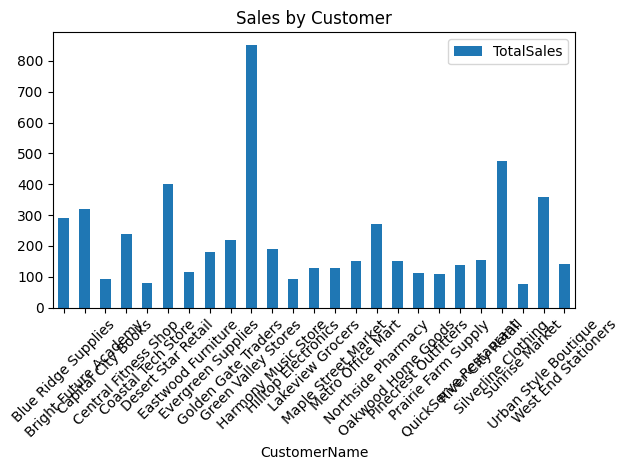

In [12]:
plt.figure()
df.plot(kind='bar', x='CustomerName', y='TotalSales')
plt.title("Sales by Customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Sales by state for all time
state_query = """
SELECT c.CustomerState, SUM(od.Quantity * i.ItemPriceUSD) AS TotalSales
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
JOIN OrderDetails od ON o.OrderID = od.OrderID
JOIN Items i ON od.ItemID = i.ItemID
GROUP BY c.CustomerState
ORDER BY TotalSales DESC
"""

state_df = pd.read_sql(state_query, conn)

state_df

C:\Users\konif\AppData\Local\Temp\ipykernel_53040\318705143.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  state_df = pd.read_sql(state_query, conn)


OperationalError: ('08S01', '[08S01] [Microsoft][ODBC Driver 18 for SQL Server]TCP Provider: An existing connection was forcibly closed by the remote host.\r\n (10054) (SQLExecDirectW); [08S01] [Microsoft][ODBC Driver 18 for SQL Server]Communication link failure (10054)')

In [14]:
# Chart: Sales by State
plt.figure()
state_df.plot(kind="bar", x="CustomerState", y="TotalSales")
plt.title("Sales by State for All Time")
plt.xlabel("Customer State")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'state_df' is not defined

<Figure size 640x480 with 0 Axes>

In [15]:
cursor.close()
conn.close()

print("Database connection closed successfully.")

Database connection closed successfully.


In [17]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost,21433;"
    "DATABASE=CustomerOrdersSalesDB;"
    "UID=sa;"
    "PWD=Classes#1234;"
    "TrustServerCertificate=yes;"
)

print("Reconnected successfully")

Reconnected successfully


In [18]:
state_query = """
SELECT c.CustomerState, SUM(od.Quantity * i.ItemPriceUSD) AS TotalSales
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
JOIN OrderDetails od ON o.OrderID = od.OrderID
JOIN Items i ON od.ItemID = i.ItemID
GROUP BY c.CustomerState
ORDER BY TotalSales DESC
"""

state_df = pd.read_sql(state_query, conn)

state_df

C:\Users\konif\AppData\Local\Temp\ipykernel_53040\3047503414.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  state_df = pd.read_sql(state_query, conn)


,CustomerState,TotalSales
0,Missouri,1325.00
1,New York,625.00
2,Virginia,451.50
3,Texas,406.00
4,Arizona,399.98
5,Illinois,346.35
6,Ohio,339.97
7,Georgia,332.50
8,California,299.92
9,Florida,269.90


<Figure size 640x480 with 0 Axes>

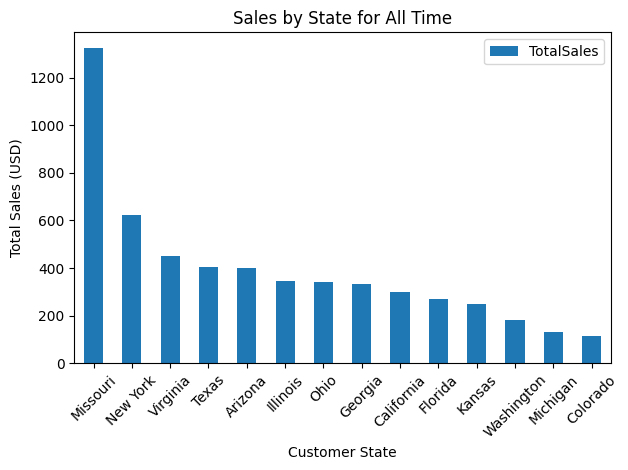

In [19]:
plt.figure()
state_df.plot(kind="bar", x="CustomerState", y="TotalSales")
plt.title("Sales by State for All Time")
plt.xlabel("Customer State")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
print(state_df.head())

  CustomerState  TotalSales
0      Missouri     1325.00
1      New York      625.00
2      Virginia      451.50
3         Texas      406.00
4       Arizona      399.98


## Conclusion

This notebook demonstrated how Python can connect to MS SQL Server, insert records into database tables, retrieve sales data using SQL queries, and create visual charts for analysis.